<a href="https://colab.research.google.com/github/pravanjangarg20/Machine_Learning_project/blob/main/mental_health/Mental_Health_Care.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import matplotlib as mpl
import matplotlib.pyplot as plt   # data visualization
import seaborn as sns             # statistical data visualization

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore')
from collections import Counter
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report,precision_recall_fscore_support
from sklearn.metrics import mean_squared_error

## Importing Data

In [2]:
import kagglehub
import os
# Download latest version
dataset_path = kagglehub.dataset_download("csafrit2/maternal-health-risk-data")

# Find the CSV file within the downloaded directory
for filename in os.listdir(dataset_path):
    if filename.endswith(".csv"):
        csv_file_path = os.path.join(dataset_path, filename)
        break  # Stop after finding the first CSV file

# Read the CSV file
df = pd.read_csv(csv_file_path)
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
df.shape

(1014, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [5]:
print(f"The dataset size: {df.shape}")

The dataset size: (1014, 7)


In [6]:
print(df['RiskLevel'].value_counts())

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


## Data Visulization

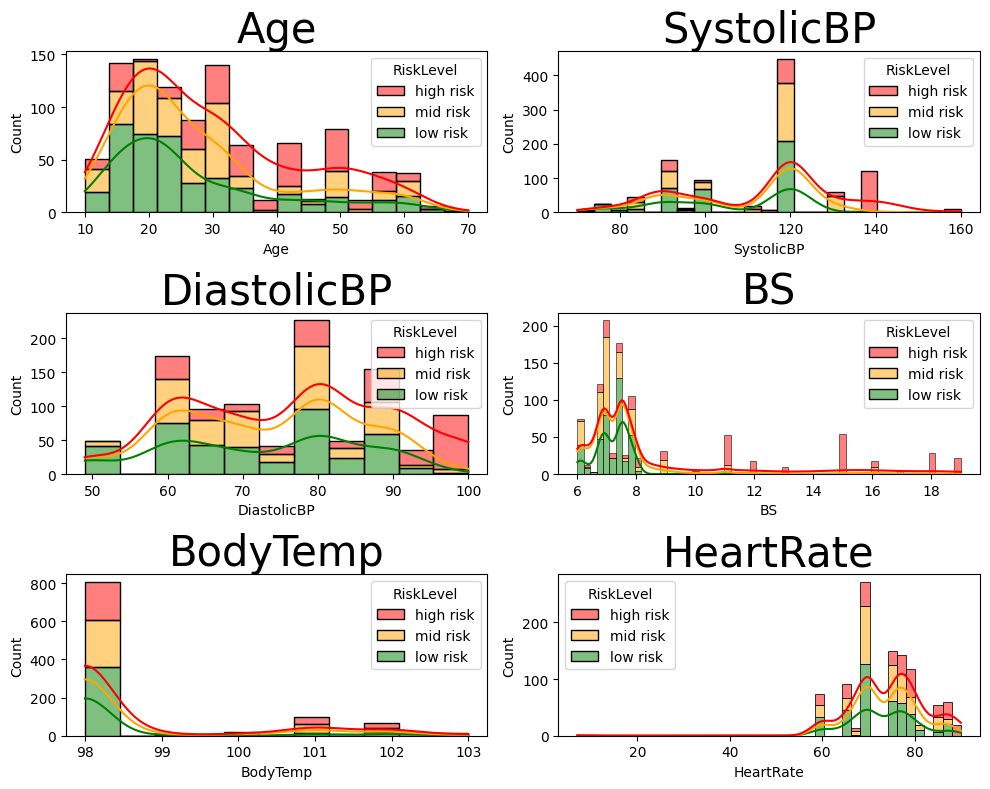

In [8]:
fig,axes=  plt.subplots(nrows=3,ncols=2,figsize=(10,8))
risk_level_order=['high risk','mid risk', 'low risk']

for ax,column in zip(axes.flatten(),df.columns):
  sns.histplot(
      data=df,
      x=column,
      kde=True,
      hue='RiskLevel',
      hue_order=risk_level_order,
      multiple='stack',
      palette={'low risk':'green','mid risk':'orange','high risk':'red'},
      element='bars', ax=ax
  )
  ax.set_title(f'{column}',fontsize=30)

plt.tight_layout()
plt.savefig('meternal_feature_description.png')
plt.show()

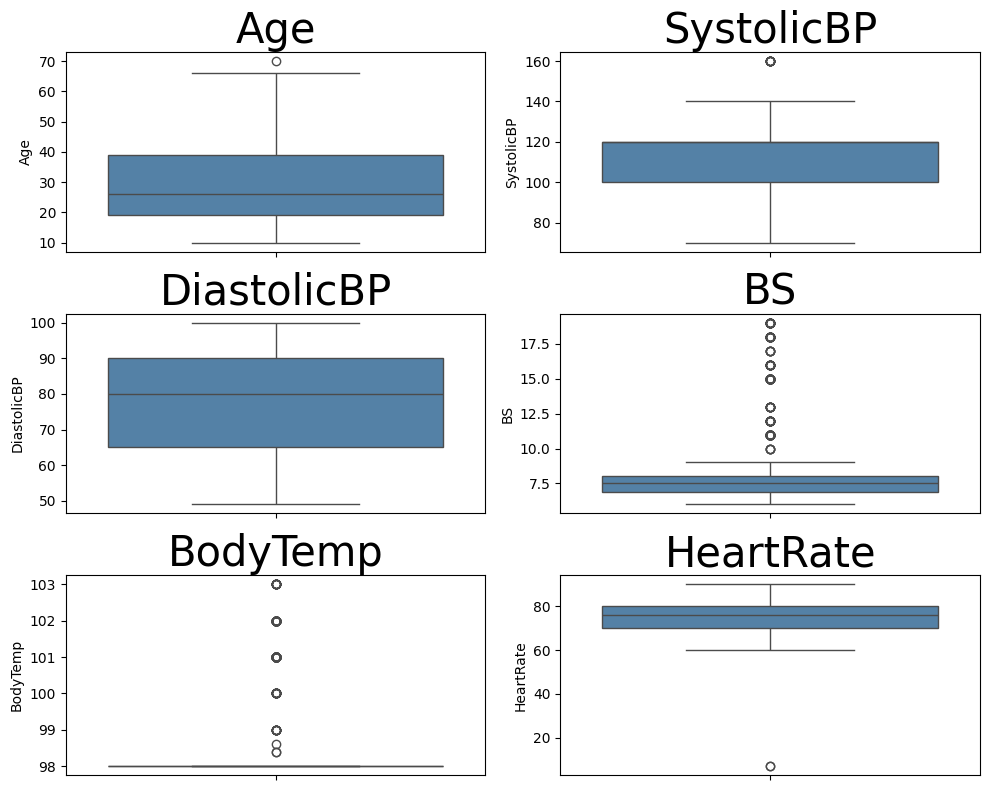

In [9]:
fig,axes=  plt.subplots(nrows=3,ncols=2,figsize=(10,8))
risk_level_order=['high risk','mid risk', 'low risk']

for ax,column in zip(axes.flatten(),df.columns):
  sns.boxplot(
      y=df[column],
      color='#4682B4',
      ax=ax
  )
  ax.set_title(f'{column}',fontsize=30)

plt.tight_layout()
plt.savefig('meternal_skewed_distribution_to_check_outlier.png')
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['RiskLevel'] = le.fit_transform(df['RiskLevel'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 55.6 KB


In [11]:
# {"low risk": 1,"mid risk": 2, "high risk":3}
df['RiskLevel'].value_counts()

,count
RiskLevel,
1,406
2,336
0,272


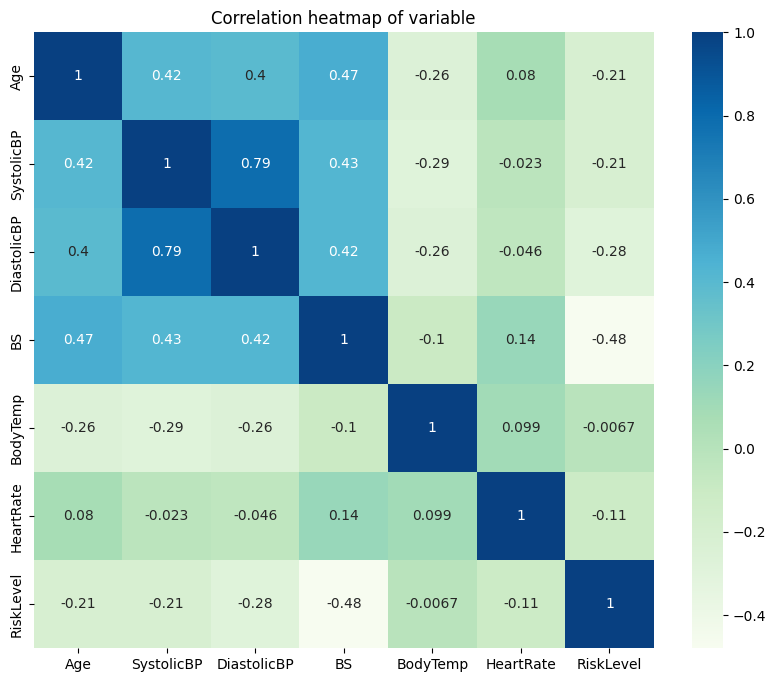

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='GnBu')
plt.title('Correlation heatmap of variable')
plt.savefig('meternal_heatmap_to_check_correlation.png')
plt.show()

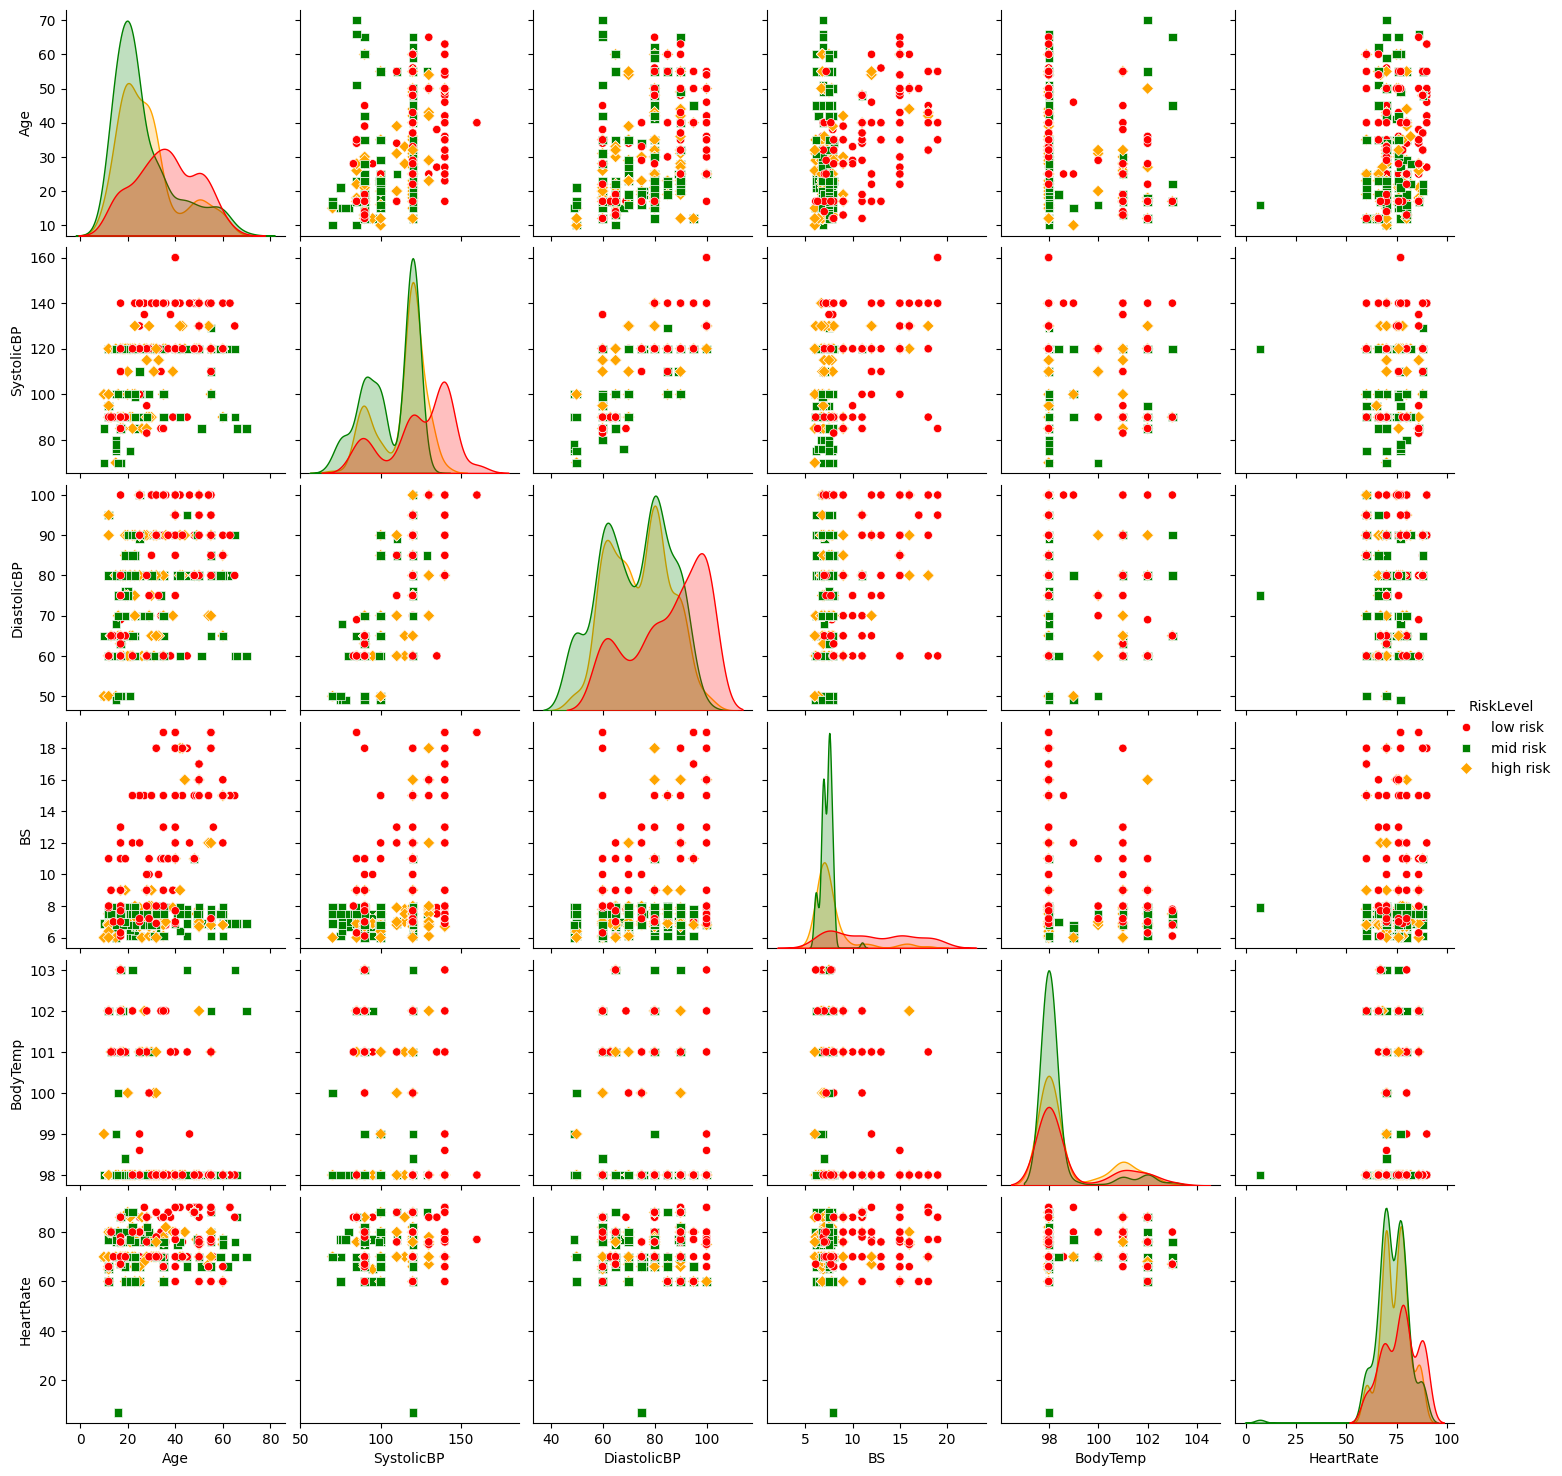

In [13]:
risk_color={1:'green', 2:'orange', 0:'red'}

plot=sns.pairplot(
    df,hue='RiskLevel',
    palette=risk_color,
    markers=['o','s','D'])
legend_labels={"1":"low risk","2":"mid risk","3": "high risk"}
for text,label in zip(plot._legend.texts,legend_labels.values()):
    text.set_text(label)
plt.savefig('meternal_pairplot_to_see_pattern.png')
plt.show()

## Feature Selection

In [14]:
x=df[['DiastolicBP','SystolicBP']]
vif_data=pd.DataFrame()
vif_data['Variable']=x.columns
vif_data['VIF']=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
vif_data

,Variable,VIF
0,DiastolicBP,79.96833
1,SystolicBP,79.96833


In [15]:
df=df.drop(['SystolicBP'],axis=1)

In [16]:
df.HeartRate.sort_values().head()

,HeartRate
499,7
908,7
1000,60
1010,60
705,60


In [17]:
df=df.drop(df.index[df.HeartRate==7])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1012 entries, 0 to 1013
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1012 non-null   int64  
 1   DiastolicBP  1012 non-null   int64  
 2   BS           1012 non-null   float64
 3   BodyTemp     1012 non-null   float64
 4   HeartRate    1012 non-null   int64  
 5   RiskLevel    1012 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 55.3 KB


In [19]:
columns=['Age', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
scale_X=StandardScaler()
X=pd.DataFrame(scale_X.fit_transform(df.drop(['RiskLevel'],axis=1)),columns=columns)
y=df['RiskLevel']

In [20]:
X.head()

,Age,DiastolicBP,BS,BodyTemp,HeartRate
0,-0.363796,0.254566,1.903633,-0.485808,1.538308
1,0.378765,0.974379,1.296644,-0.485808,-0.589878
2,-0.066772,-0.465247,-0.220828,0.972192,0.740239
3,0.007484,0.614473,-0.524323,-0.485808,-0.589878
4,0.378765,-1.185059,-0.797468,-0.485808,0.208192


In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y, train_size=0.8,random_state=42, stratify=y)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((809, 5), (203, 5), (809,), (203,))

## Logistic Regression

In [22]:
#BaseLine model of Logistic Regression
LR=LogisticRegression()
logistic_regression_mod=LR.fit(X_train,y_train)
print(f"BaseLine Logistic Regression:{round(logistic_regression_mod.score(X_test,y_test),3)}")
predicted_logistic_reg=logistic_regression_mod.predict(X_test)

BaseLine Logistic Regression:0.606


In [23]:
# Cross Validation Logistic Regression
score_logistic=cross_val_score(LR,X,y,cv=3,scoring='accuracy')
print(f"Score (Cross Validation) for Logistic Regression:\n{score_logistic}")
print(f"CrossValMean:{round(score_logistic.mean(),3)}")
print(f'CrossValStd:{round(score_logistic.std(),3)}')

Score (Cross Validation) for Logistic Regression:
[0.57988166 0.5578635  0.59050445]
CrossValMean:0.576
CrossValStd:0.014


In [24]:
params_LR={
    'tol':[0.0001,0.0002,0.0003],
    'C':[0.01,0.1,1,10,100],
    'intercept_scaling':[1,2,3,4],
    'solver':['liblinear','lbfgs','newton-cg'],
    'max_iter':[100,200,300]
}

In [25]:
GridSearchCV_LR=GridSearchCV(estimator=LR,
                             param_grid=params_LR,
                             cv=3,scoring='accuracy',
                             return_train_score=True)
GridSearchCV_LR.fit(X_train,y_train)

GridSearchCV(cv=3, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'intercept_scaling': [1, 2, 3, 4],
                         'max_iter': [100, 200, 300],
                         'solver': ['liblinear', 'lbfgs', 'newton-cg'],
                         'tol': [0.0001, 0.0002, 0.0003]},
             return_train_score=True, scoring='accuracy')

In [26]:
print(f"Best estimator for LR model:\n{GridSearchCV_LR.best_estimator_}")
print(f"Best parameter value for LR model:\n{GridSearchCV_LR.best_params_}")
print(f"Best score for LR model:\n {round(GridSearchCV_LR.best_score_),3}")

Best estimator for LR model:
LogisticRegression(C=10, solver='liblinear', tol=0.0002)
Best parameter value for LR model:
{'C': 10, 'intercept_scaling': 1, 'max_iter': 100, 'solver': 'liblinear', 'tol': 0.0002}
Best score for LR model:
 (1, 3)


In [27]:
logistic_regression=LogisticRegression(C=0.01,intercept_scaling=1,max_iter=100,solver='liblinear',tol=0.001,random_state=42)
logistic_regression_mod=logistic_regression.fit(X_train,y_train)
predicted_logistic_reg=logistic_regression_mod.predict(X_test)

mse_logistic_regression=mean_squared_error(y_test,predicted_logistic_reg)
rmse_logistic_regression=np.sqrt(mse_logistic_regression)
score_logistic_regression_train=logistic_regression_mod.score(X_train,y_train)
score_logistic_regression_test=logistic_regression_mod.score(X_test,y_test)

In [28]:
print(f"Mean Square Error for Logistic Regression = {round(mse_logistic_regression,3)}")
print(f"Root Mean Square Error for Logistic Regression ={round(rmse_logistic_regression,3)}")
print(f"R^2 (coefficient of determination) on training set = {round(score_logistic_regression_train,3)}")
print(f"R^2 (coefficient of determination) on testing set:{round(score_logistic_regression_test,3)}")

Mean Square Error for Logistic Regression = 0.542
Root Mean Square Error for Logistic Regression =0.736
R^2 (coefficient of determination) on training set = 0.617
R^2 (coefficient of determination) on testing set:0.606


In [29]:
print('Classification Report')
print(classification_report(y_test,predicted_logistic_reg))
print('Confusion Matrix')
print(confusion_matrix(y_test,predicted_logistic_reg))

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.75      0.81        55
           1       0.54      0.86      0.67        81
           2       0.43      0.18      0.25        67

    accuracy                           0.61       203
   macro avg       0.62      0.60      0.58       203
weighted avg       0.60      0.61      0.57       203

Confusion Matrix
[[41  7  7]
 [ 2 70  9]
 [ 3 52 12]]


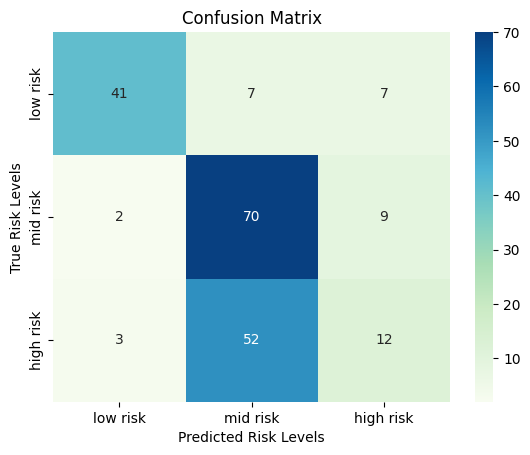

In [30]:
fig, ax = plt.subplots() # Unpack the tuple into fig and ax
sns.heatmap(confusion_matrix(y_test,predicted_logistic_reg),annot=True,ax=ax,cmap='GnBu')
ax.set_xlabel('Predicted Risk Levels');
ax.set_ylabel('True Risk Levels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['low risk','mid risk','high risk']);
ax.yaxis.set_ticklabels(['low risk','mid risk','high risk']);

## KNeighborsClassifier

In [31]:
knn=KNeighborsClassifier()
knn_mod=knn.fit(X_train,y_train)
print(f"BaseLine K-Nearest Neighbors:{round(knn_mod.score(X_test,y_test),3)}")
predicted_knn=knn_mod.predict(X_test)

BaseLine K-Nearest Neighbors:0.675


In [32]:
# Cross Validation K-Nearest Neighbors
score_knn=cross_val_score(knn,X,y,cv=3,scoring='accuracy')
print(f"Score (Cross Validation) for K-Nearest Neighbors:\n{score_knn}")
print(f"CrossValMean:{round(score_knn.mean(),3)}")
print(f'CrossValStd:{round(score_knn.std(),3)}')

Score (Cross Validation) for K-Nearest Neighbors:
[0.66272189 0.64688427 0.70029674]
CrossValMean:0.67
CrossValStd:0.022


In [33]:
params_knn={
    'leaf_size':list(range(1,30)),
    'n_neighbors':list(range(1,21)),
    'p':[1,2],
    'weights':['uniform','distance']
}

In [34]:
GridSearchCV_knn=GridSearchCV(estimator=knn,
                             param_grid=params_knn,
                             cv=3,scoring='accuracy',
                             return_train_score=True)
GridSearchCV_knn.fit(X_train,y_train)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'leaf_size': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                       23, 24, 25, 26, 27, 28, 29],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             return_train_score=True, scoring='accuracy')

In [35]:
print(f"Best estimator for KNN model:\n{GridSearchCV_knn.best_estimator_}")
print(f"Best parameter value for KNN model:\n{GridSearchCV_knn.best_params_}")
print(f"Best score for KNN model:\n {round(GridSearchCV_knn.best_score_),3}")

Best estimator for KNN model:
KNeighborsClassifier(leaf_size=1, n_neighbors=19, weights='distance')
Best parameter value for KNN model:
{'leaf_size': 1, 'n_neighbors': 19, 'p': 2, 'weights': 'distance'}
Best score for KNN model:
 (1, 3)


In [41]:
knn=KNeighborsClassifier(leaf_size=1,n_neighbors=10,p=2, weights='distance') # Changed 'random_states' to 'random_state'
knn_mod=knn.fit(X_train,y_train)
predicted_knn=knn_mod.predict(X_test)

mse_knn=mean_squared_error(y_test,predicted_knn)
rmse_knn=np.sqrt(mse_knn)
score_knn_train=knn_mod.score(X_train,y_train)
score_knn_test=knn_mod.score(X_test,y_test)

In [42]:
print(f"Mean Square Error for K-Nearest Neighbors = {round(mse_knn,3)}")
print(f"Root Mean Square Error for K-Nearest Neighbors ={round(rmse_knn,3)}")
print(f"R^2 (coefficient of determination) on training set = {round(score_knn_train,3)}")
print(f"R^2 (coefficient of determination) on testing set:{round(score_knn_test,3)}")

Mean Square Error for K-Nearest Neighbors = 0.291
Root Mean Square Error for K-Nearest Neighbors =0.539
R^2 (coefficient of determination) on training set = 0.93
R^2 (coefficient of determination) on testing set:0.813


In [43]:
print('Classification Report')
print(classification_report(y_test,predicted_knn))
print('Confusion Matrix')
print(confusion_matrix(y_test,predicted_knn))

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.87      0.90        55
           1       0.86      0.74      0.79        81
           2       0.70      0.85      0.77        67

    accuracy                           0.81       203
   macro avg       0.83      0.82      0.82       203
weighted avg       0.82      0.81      0.81       203

Confusion Matrix
[[48  2  5]
 [ 2 60 19]
 [ 2  8 57]]


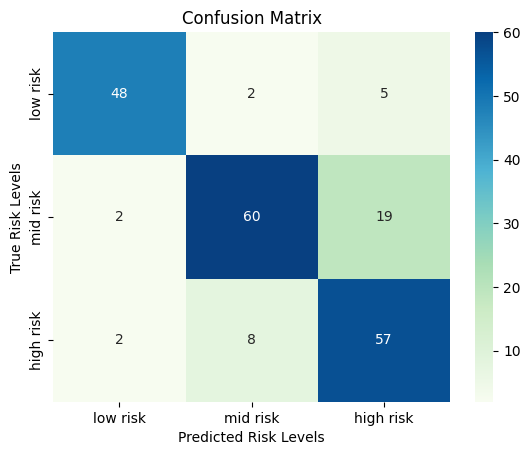

In [44]:
fig, ax = plt.subplots() # Unpack the tuple into fig and ax
sns.heatmap(confusion_matrix(y_test,predicted_knn),annot=True,ax=ax,cmap='GnBu')
ax.set_xlabel('Predicted Risk Levels');
ax.set_ylabel('True Risk Levels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['low risk','mid risk','high risk']);
ax.yaxis.set_ticklabels(['low risk','mid risk','high risk']);

## Random Forest Classifier

In [45]:
RF=RandomForestClassifier()
RF_mod=RF.fit(X_train,y_train)
print(f"BaseLine Random Forest:{round(RF_mod.score(X_test,y_test),3)}")
predicted_RF=RF_mod.predict(X_test)

BaseLine Random Forest:0.867


In [46]:
# Cross Validation Random Forest
score_RF=cross_val_score(RF,X,y,cv=3,scoring='accuracy')
print(f"Score (Cross Validation) for Random Forest:\n{score_knn}")
print(f"CrossValMean:{round(score_knn.mean(),3)}")
print(f'CrossValStd:{round(score_knn.std(),3)}')

Score (Cross Validation) for Random Forest:
[0.66272189 0.64688427 0.70029674]
CrossValMean:0.67
CrossValStd:0.022


In [47]:
params_RF={
    'min_samples_split':[2,6,20],
    'min_samples_leaf':[1,2,4],
    'n_estimators':[50,100,200,300,400],
    'max_depth':[None,10,20,30],
    'criterion':['gini','entropy']
}

In [48]:
GridSearchCV_RF=GridSearchCV(estimator=RandomForestClassifier(),
                             param_grid=params_RF,
                             cv=3,scoring='accuracy',
                             return_train_score=True)
GridSearchCV_RF.fit(X_train,y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 6, 20],
                         'n_estimators': [50, 100, 200, 300, 400]},
             return_train_score=True, scoring='accuracy')

In [49]:
print(f"Best estimator for KNN model:\n{GridSearchCV_RF.best_estimator_}")
print(f"Best parameter value for KNN model:\n{GridSearchCV_RF.best_params_}")
print(f"Best score for KNN model:\n {round(GridSearchCV_RF.best_score_),3}")

Best estimator for KNN model:
RandomForestClassifier(n_estimators=400)
Best parameter value for KNN model:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best score for KNN model:
 (1, 3)


In [50]:
RF=RandomForestClassifier(criterion='entropy',max_depth=30,min_samples_leaf=1,min_samples_split=2,n_estimators=400,random_state=42)
RF_mod=RF.fit(X_train,y_train)
predicted_RF=RF_mod.predict(X_test)

mse_RF=mean_squared_error(y_test,predicted_RF)
rmse_RF=np.sqrt(mse_RF)
score_RF_train=RF_mod.score(X_train,y_train)
score_RF_test=RF_mod.score(X_test,y_test)

In [51]:
print(f"Mean Square Error for Random Forest = {round(mse_RF,3)}")
print(f"Root Mean Square Error for Random Forest ={round(rmse_RF,3)}")
print(f"R^2 (coefficient of determination) on training set = {round(score_RF_train,3)}")
print(f"R^2 (coefficient of determination) on testing set:{round(score_RF_test,3)}")

Mean Square Error for Random Forest = 0.212
Root Mean Square Error for Random Forest =0.46
R^2 (coefficient of determination) on training set = 0.93
R^2 (coefficient of determination) on testing set:0.862


In [52]:
print('Classification Report')
print(classification_report(y_test,predicted_RF))
print('Confusion Matrix')
print(confusion_matrix(y_test,predicted_RF))

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        55
           1       0.91      0.79      0.85        81
           2       0.77      0.90      0.83        67

    accuracy                           0.86       203
   macro avg       0.87      0.87      0.87       203
weighted avg       0.87      0.86      0.86       203

Confusion Matrix
[[51  1  3]
 [ 2 64 15]
 [ 2  5 60]]


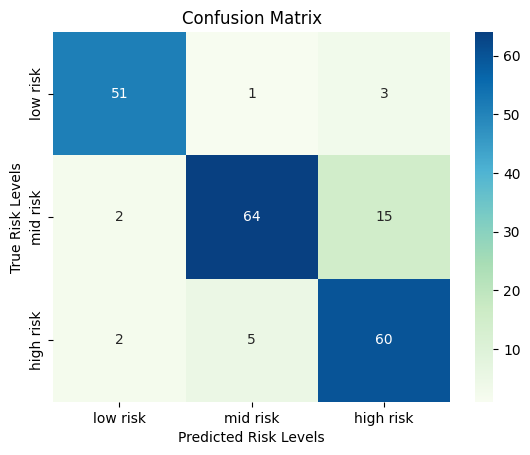

In [53]:
fig, ax = plt.subplots() # Unpack the tuple into fig and ax
sns.heatmap(confusion_matrix(y_test,predicted_RF),annot=True,ax=ax,cmap='GnBu')
ax.set_xlabel('Predicted Risk Levels');
ax.set_ylabel('True Risk Levels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['low risk','mid risk','high risk']);
ax.yaxis.set_ticklabels(['low risk','mid risk','high risk']);

## Gradient Boosting Classifier

In [54]:
gbc=GradientBoostingClassifier()
gbc_mod=gbc.fit(X_train,y_train)
print(f"BaseLine Gradient Boosting:{round(gbc_mod.score(X_test,y_test),3)}")
predicted_gbc=gbc_mod.predict(X_test)

BaseLine Gradient Boosting:0.798


In [55]:
score_gbc=cross_val_score(gbc,X,y,cv=3,scoring='accuracy')
print(f"Score (Cross Validation) for Gradient Boost:\n{score_gbc}")
print(f"CrossValMean:{round(score_gbc.mean(),3)}")
print(f'CrossValStd:{round(score_gbc.std(),3)}')


Score (Cross Validation) for Gradient Boost:
[0.67751479 0.70029674 0.77151335]
CrossValMean:0.716
CrossValStd:0.04


In [56]:
parans_gbc={
    'loss':['log_loss'], # Changed 'deviance' to 'log_loss'
    'learning_rate':[0.01,0.05,0.075,0.1],
    'n_estimators':[100,250,500],
    'max_depth':[3,5,8,10],
    'subsample':[0.8,1.0]
}

In [57]:

GridSearchCV_gcb=GridSearchCV(estimator=GradientBoostingClassifier(),
                             param_grid=parans_gbc, # Changed to parans_gbc
                             cv=3,scoring='accuracy',
                             return_train_score=True)
GridSearchCV_gcb.fit(X_train,y_train)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.05, 0.075, 0.1],
                         'loss': ['log_loss'], 'max_depth': [3, 5, 8, 10],
                         'n_estimators': [100, 250, 500],
                         'subsample': [0.8, 1.0]},
             return_train_score=True, scoring='accuracy')

In [58]:
gbc = GradientBoostingClassifier(learning_rate=0.5, loss='log_loss', max_depth=10, n_estimators=100, subsample=1, random_state=42)
# The 'loss' parameter has been changed to 'log_loss' to comply with the current acceptable values.
gbc_mod = gbc.fit(X_train, y_train)
predicted_gbc = gbc_mod.predict(X_test)

mse_gbc = mean_squared_error(y_test, predicted_gbc)
rmse_gbc = np.sqrt(mse_gbc)
score_gbc_train = gbc_mod.score(X_train, y_train)
score_gbc_test = gbc_mod.score(X_test, y_test)

In [59]:
print(f"Mean Square Error for Random Forest = {round(mse_gbc,3)}")
print(f"Root Mean Square Error for Random Forest ={round(rmse_gbc,3)}")
print(f"R^2 (coefficient of determination) on training set = {round(score_gbc_train,3)}")
print(f"R^2 (coefficient of determination) on testing set:{round(score_gbc_test,3)}")

Mean Square Error for Random Forest = 0.227
Root Mean Square Error for Random Forest =0.476
R^2 (coefficient of determination) on training set = 0.93
R^2 (coefficient of determination) on testing set:0.862


In [60]:
print('Classification Report')
print(classification_report(y_test,predicted_gbc))
print('Confusion Matrix')
print(confusion_matrix(y_test,predicted_gbc))

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        55
           1       0.93      0.79      0.85        81
           2       0.77      0.90      0.83        67

    accuracy                           0.86       203
   macro avg       0.87      0.87      0.87       203
weighted avg       0.87      0.86      0.86       203

Confusion Matrix
[[51  0  4]
 [ 3 64 14]
 [ 2  5 60]]


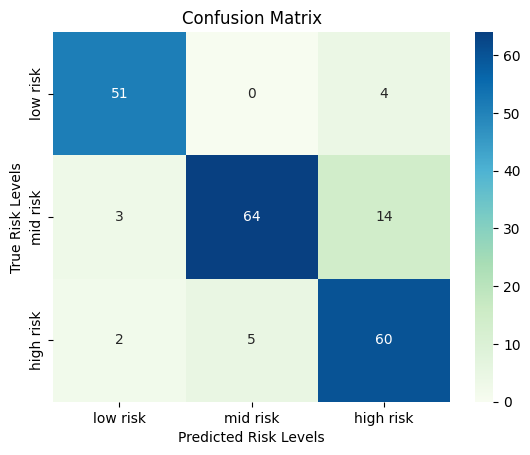

In [61]:

fig, ax = plt.subplots() # Unpack the tuple into fig and ax
sns.heatmap(confusion_matrix(y_test,predicted_gbc),annot=True,ax=ax,cmap='GnBu')
ax.set_xlabel('Predicted Risk Levels');
ax.set_ylabel('True Risk Levels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['low risk','mid risk','high risk']);
ax.yaxis.set_ticklabels(['low risk','mid risk','high risk']);

In [62]:
results=pd.DataFrame({
    'Model':['Logistic Regression','K-Nearest Neighbors','Random Forest','Gradient Boosting Classifier'],
    'Train Score"':[
        cross_val_score(logistic_regression_mod,X_train,y_train, cv=3).mean()
        ,cross_val_score(knn_mod,X_train,y_train, cv=3).mean()
        ,cross_val_score(RF_mod,X_train,y_train, cv=3).mean()
        ,cross_val_score(gbc_mod,X_train,y_train, cv=3).mean()
    ],
    'Test Score':[
        logistic_regression_mod.score(X_test,y_test)
        ,knn_mod.score(X_test,y_test)
        ,RF_mod.score(X_test,y_test),
        gbc_mod.score(X_test,y_test)
    ]
})

metrics=['percision','recall','f1-score']
for metric in metrics:
  results[f"{metric.capitalize()}"]=[
      # Corrected the function name from 'percision_recall_fscore_support' to 'precision_recall_fscore_support'
      precision_recall_fscore_support(y_test,model.predict(X_test),average='weighted')[metrics.index(metric)]
      for model in [logistic_regression_mod,knn_mod,RF_mod,gbc_mod]
  ]

result_df=results.sort_values(by='Test Score',ascending=False)
result_df

,Model,"Train Score""",Test Score,Percision,Recall,F1-score
3,Gradient Boosting Classifier,0.799702,0.862069,0.870730,0.862069,0.862605
2,Random Forest,0.796012,0.862069,0.869929,0.862069,0.862613
1,K-Nearest Neighbors,0.765129,0.812808,0.824364,0.812808,0.814408
0,Logistic Regression,0.606944,0.605911,0.599456,0.605911,0.569359


In [63]:
import pickle

In [64]:
pickle.dump(gbc_mod,open('finalize_maternal_model.sav','wb'))

In [65]:
import sklearn
sklearn.__version__

'1.6.1'